# Linear Regression Masterclass: Lab Session
This notebook covers the end-to-end implementation of Linear Regression including:
1. Supervised vs Unsupervised overview
2. Identifying Dependent/Independent Variables
3. Finding the Best Fit Line
4. Measuring Cost (MSE) and Metrics (R2, RMSE)
5. Residual Analysis (Assumptions Check)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Setting a professional style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_r")

## 1. Data Preparation
We will generate synthetic data representing **Years of Experience** (Independent Variable) and **Annual Salary** (Dependent Variable).

In [9]:
np.random.seed(42)
experience = np.random.normal(5, 2.5, 200)
salary = 20000 + (experience * 7500) + np.random.normal(0, 4000, 200)

df = pd.DataFrame({'YearsExp': experience, 'Salary': salary})
df = df[df['YearsExp'] > 0] # Filter out negative years

print(df.head())

   YearsExp        Salary
0  6.241785  68244.539810
1  4.654339  57150.682459
2  6.619221  73976.365062
3  8.807575  90272.018016
4  4.414617  47598.946752


## 2. Exploratory Data Analysis
Checking for the **Linearity Assumption** and visualizing the **regression trend line**.


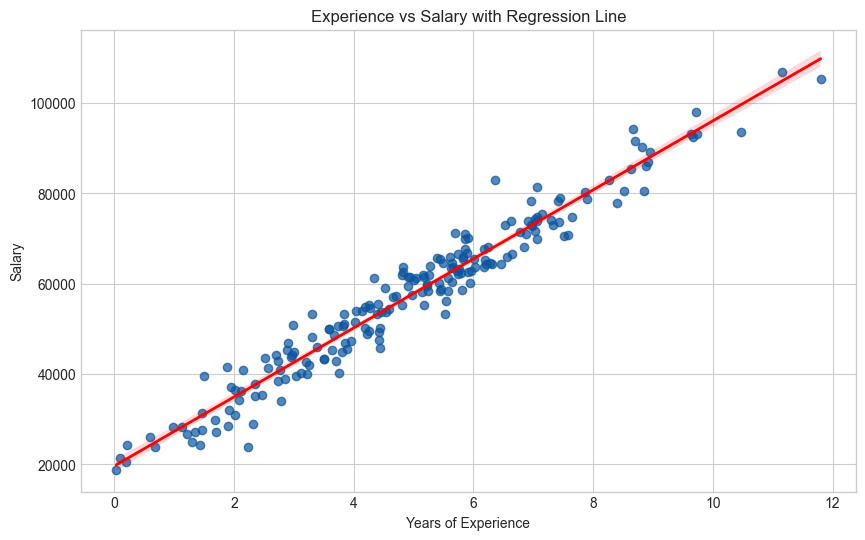

In [10]:
plt.figure(figsize=(10,6))
sns.regplot(data=df, x='YearsExp', y='Salary', scatter_kws={'alpha':0.7}, line_kws={'color':'red', 'linewidth':2})
plt.title('Experience vs Salary with Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

### Gradient Descent Intuition (Small Example)
Below, we use a tiny synthetic dataset and run gradient descent step-by-step to visually show how the line parameters update from a poor initial guess toward the best fit.


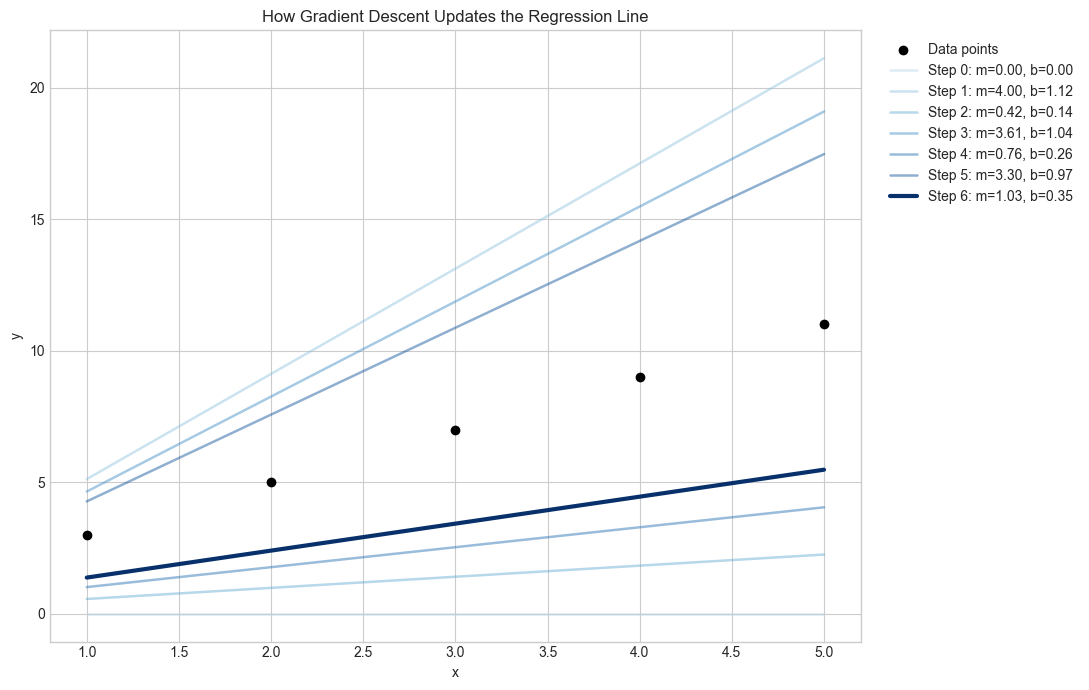

Final parameters after 6 steps: slope (m) = 1.0253, intercept (b) = 0.3516


In [11]:
# Small example to visualize gradient descent
x_small = np.array([1, 2, 3, 4, 5], dtype=float)
y_small = np.array([3, 5, 7, 9, 11], dtype=float)  # roughly y = 2x + 1

m, b = 0.0, 0.0  # starting parameters
learning_rate = 0.08
steps = 6
history = []
n = len(x_small)

for step in range(steps):
    y_pred = m * x_small + b
    dm = (-2/n) * np.sum(x_small * (y_small - y_pred))
    db = (-2/n) * np.sum(y_small - y_pred)
    history.append((step, m, b))
    m -= learning_rate * dm
    b -= learning_rate * db

history.append((steps, m, b))

# Plot progression of fitted lines
plt.figure(figsize=(11, 7))
plt.scatter(x_small, y_small, color='black', label='Data points', zorder=3)

colors = plt.cm.Blues(np.linspace(0.3, 1, len(history)))
for i, (step, m_h, b_h) in enumerate(history):
    y_line = m_h * x_small + b_h
    label = f'Step {step}: m={m_h:.2f}, b={b_h:.2f}'
    alpha = 0.45 if step < steps else 1.0
    lw = 1.8 if step < steps else 3
    plt.plot(x_small, y_line, color=colors[i], alpha=alpha, linewidth=lw, label=label)

plt.title('How Gradient Descent Updates the Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f'Final parameters after {steps} steps: slope (m) = {m:.4f}, intercept (b) = {b:.4f}')

## 3. Modeling: Best Fit Line
Splitting the data into training and testing sets to evaluate performance on unseen data.

In [12]:
X = df[['YearsExp']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Learned Slope (Coeff): {model.coef_[0]:.2f}")
print(f"Learned Intercept: {model.intercept_:.2f}")

Learned Slope (Coeff): 7666.96
Learned Intercept: 19650.15


## 4. Evaluation Metrics
Calculating the metrics we discussed in the slides.

MAE: 2852.327461026619
MSE: 12923413.239371184
RMSE: 3594.914914065587
R-Squared Score: 0.9644950251974183


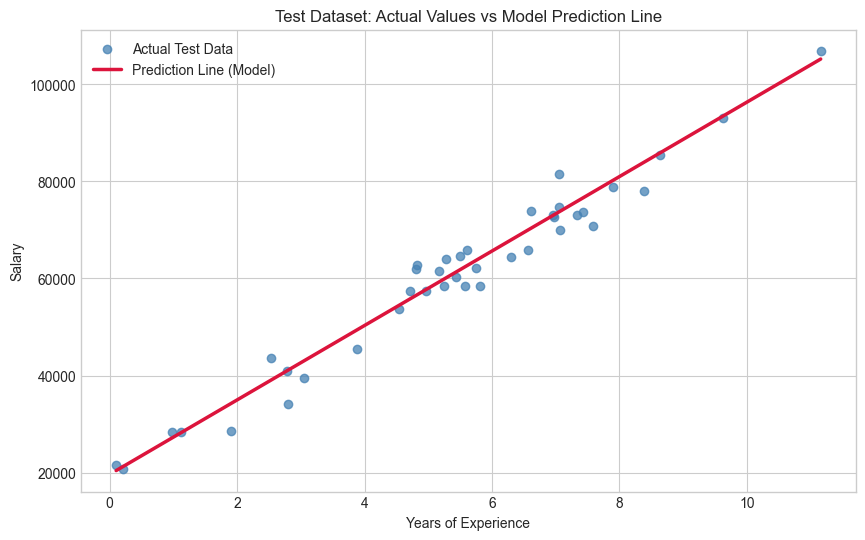

In [14]:
predictions = model.predict(X_test)

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R-Squared Score:', metrics.r2_score(y_test, predictions))

# Plot actual test points and regression prediction line
X_test_sorted = X_test.copy()
X_test_sorted['ActualSalary'] = y_test.values
X_test_sorted['PredictedSalary'] = predictions
X_test_sorted = X_test_sorted.sort_values('YearsExp')

plt.figure(figsize=(10,6))
plt.scatter(X_test_sorted['YearsExp'], X_test_sorted['ActualSalary'], color='steelblue', alpha=0.75, label='Actual Test Data')
plt.plot(X_test_sorted['YearsExp'], X_test_sorted['PredictedSalary'], color='crimson', linewidth=2.5, label='Prediction Line (Model)')
plt.title('Test Dataset: Actual Values vs Model Prediction Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

## 5. Checking Assumptions: Residual Plot
Checking for **Normality** and **Homoscedasticity** of Errors.

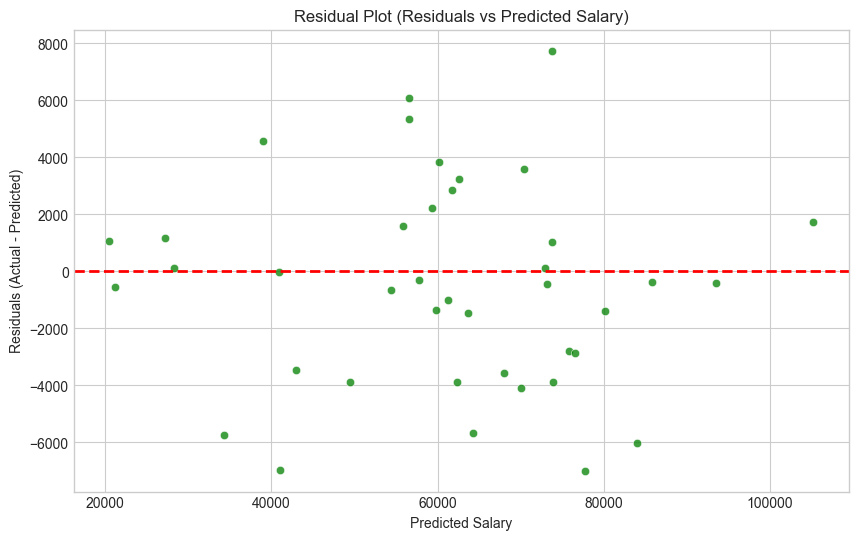

In [15]:
residuals = y_test - predictions

plt.figure(figsize=(10,6))
sns.scatterplot(x=predictions, y=residuals, color='green', alpha=0.75)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot (Residuals vs Predicted Salary)')
plt.xlabel('Predicted Salary')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()